# Research Questions   
Does humidity have a measurable effect on electricity consumption?

Are there seasonal patterns in how humidity impacts demand?

In [22]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import data 
data = pd.read_csv("/Users/jiehni/monash/ads1002/ADS1002-project/data/processed/master_data.csv")

print(data.shape)

# drop missing values
print(data["Humidity (%)"].isna().sum())
data = data.dropna(subset=["Humidity (%)"])
print(data["Humidity (%)"].isna().sum())

(1680717, 8)
1309
0


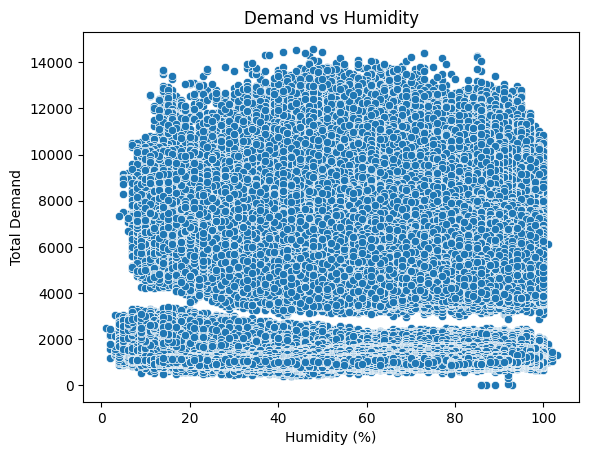

/Users/jiehni/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


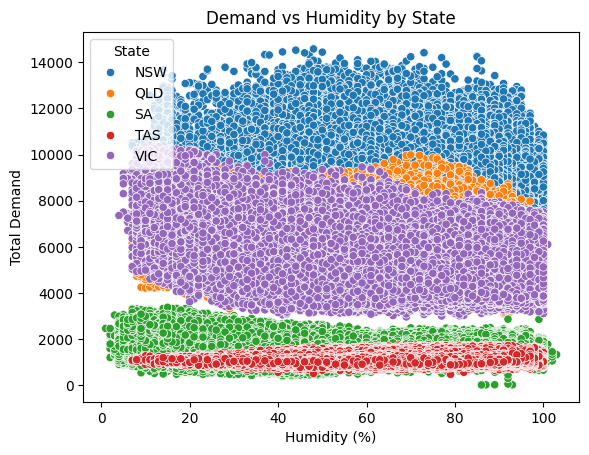

In [29]:
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand")
plt.title("Demand vs Humidity")
plt.show()

sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand", hue="State")
plt.title("Demand vs Humidity by State")
plt.show()

/Users/jiehni/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


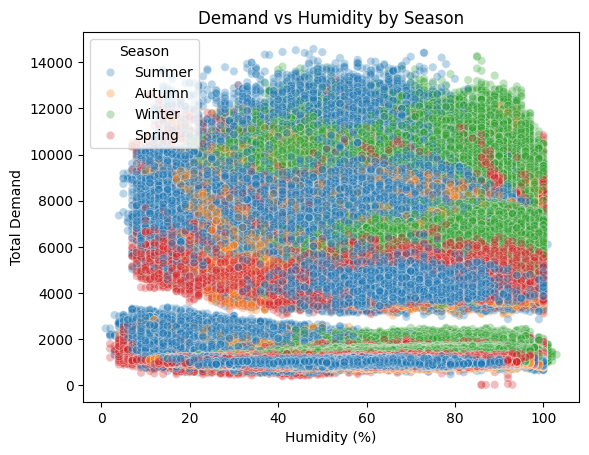

In [30]:
# extract month
data["Month"] = pd.to_datetime(data["Datetime"]).dt.month

# convert month to season
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"
data["Season"] = data["Month"].apply(get_season)

# plot by season
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand", hue="Season", alpha=0.3)
plt.title("Demand vs Humidity by Season")
plt.show()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_53853/2862905106.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()


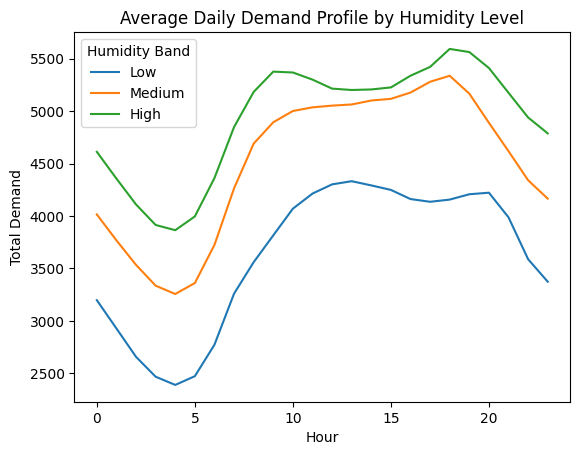

In [24]:
data["Humidity Band"] = pd.cut(data["Humidity (%)"], bins=[0,40,70,100], labels=["Low","Medium","High"])

data["Datetime"] = pd.to_datetime(data["Datetime"])
data["Hour"] = data["Datetime"].dt.hour

hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()

sns.lineplot(data=hourly, x="Hour", y="Total Demand", hue="Humidity Band")
plt.title("Average Daily Demand Profile by Humidity Level")
plt.show()

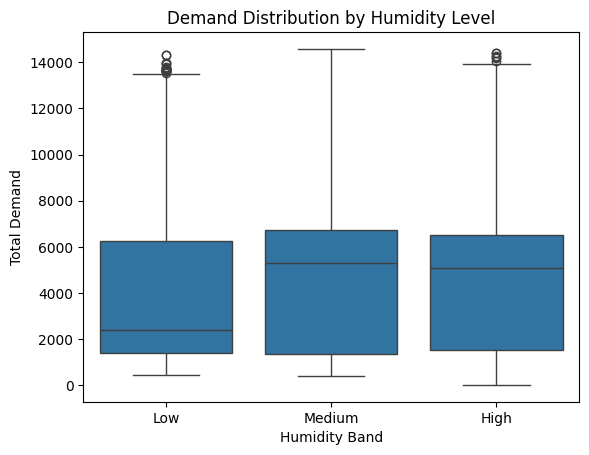

In [25]:
sns.boxplot(data=data, x="Humidity Band", y="Total Demand")
plt.title("Demand Distribution by Humidity Level")
plt.show()